CNNs — Image Classification on MNIST

 Code — Full MNIST Pipeline

Using device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 341kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.17MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.3MB/s]


Train samples: 60000
Test samples:  10000
Batches/epoch: 938

Batch shape: torch.Size([64, 1, 28, 28])
Label shape: torch.Size([64])
Pixel range: [-0.42, 2.82]


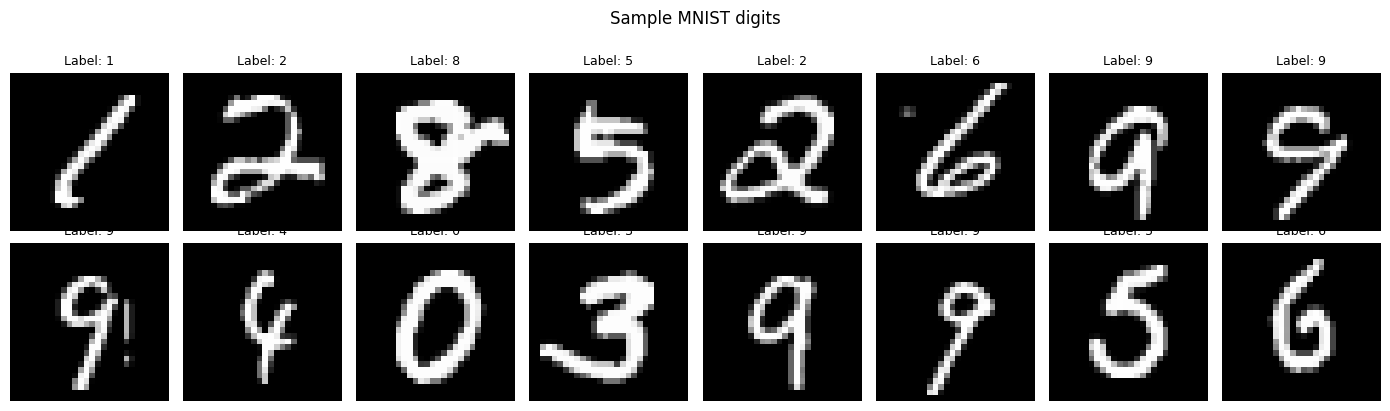

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Download MNIST ─────────────────────────────────────────────────────────
# transforms.ToTensor():     PIL image (0-255) → tensor (0.0-1.0)
# transforms.Normalize():    shift mean to 0, std to 1 → helps training
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST global mean & std
])

train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=0)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")
print(f"Batches/epoch: {len(train_loader)}")

# Peek at the data
images, labels = next(iter(train_loader))
print(f"\nBatch shape: {images.shape}")   # (64, 1, 28, 28) — batch, channels, H, W
print(f"Label shape: {labels.shape}")    # (64,)
print(f"Pixel range: [{images.min():.2f}, {images.max():.2f}]")

# Visualise some digits
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f"Label: {labels[i].item()}", fontsize=9)
    ax.axis('off')
plt.suptitle("Sample MNIST digits", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

Section A — Baseline: fully connected (to see why CNNs are better)


In [3]:
print("=" * 55)
print("SECTION A: Baseline — Fully Connected Network")
print("=" * 55)

class FCBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),                       # (1,28,28) → (784,)
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10)                  # 10 classes, no softmax
        )

    def forward(self, x):
        return self.net(x)

fc_model = FCBaseline().to(device)
total_params = sum(p.numel() for p in fc_model.parameters())
print(f"FC model parameters: {total_params:,}")  # ~235K params

# Quick training — 3 epochs just to see baseline accuracy
optimizer = torch.optim.Adam(fc_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        out  = model(images)
        loss = criterion(out, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            out  = model(images)
            loss = criterion(out, labels)
            total_loss += loss.item()
            correct    += (out.argmax(1) == labels).sum().item()
            total      += labels.size(0)
    return total_loss / len(loader), correct / total

print("\nTraining FC baseline (3 epochs)...")
for epoch in range(3):
    tr_loss, tr_acc = train_epoch(fc_model, train_loader, optimizer, criterion)
    te_loss, te_acc = eval_epoch(fc_model, test_loader, criterion)
    print(f"  Epoch {epoch+1} | train {tr_acc*100:.1f}% | test {te_acc*100:.1f}%")

SECTION A: Baseline — Fully Connected Network
FC model parameters: 235,146

Training FC baseline (3 epochs)...
  Epoch 1 | train 93.0% | test 96.6%
  Epoch 2 | train 97.0% | test 97.2%
  Epoch 3 | train 97.8% | test 97.7%


Section B — CNN: the real thing


In [4]:


# --------------------------------------------------
# Device setup
# --------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\n" + "=" * 55)
print("SECTION B: CNN — Full Architecture")
print("=" * 55)

# --------------------------------------------------
# CNN Model
# --------------------------------------------------
class MnistCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # ── Feature Extraction Block 1 ─────────────────────
        self.conv_block1 = nn.Sequential(

            # Input:  (1, 28, 28)
            # Output: (32, 28, 28)
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(),

            # Input:  (32, 28, 28)
            # Output: (32, 28, 28)
            nn.Conv2d(
                in_channels=32,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(),

            # Output: (32, 14, 14)
            nn.MaxPool2d(2),

            nn.Dropout2d(0.25)
        )

        # ── Feature Extraction Block 2 ─────────────────────
        self.conv_block2 = nn.Sequential(

            # Input:  (32, 14, 14)
            # Output: (64, 14, 14)
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(),

            # Input:  (64, 14, 14)
            # Output: (64, 14, 14)
            nn.Conv2d(
                in_channels=64,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(),

            # Output: (64, 7, 7)
            nn.MaxPool2d(2),

            nn.Dropout2d(0.25)
        )

        # ── Classifier ─────────────────────────────────────
        self.classifier = nn.Sequential(

            # (64, 7, 7) → 3136
            nn.Flatten(),

            nn.Linear(64 * 7 * 7, 256),

            nn.BatchNorm1d(256),

            nn.ReLU(),

            nn.Dropout(0.5),

            # Final Output Layer
            nn.Linear(256, 10)
        )

    # --------------------------------------------------
    # Forward Pass
    # --------------------------------------------------
    def forward(self, x):

        x = self.conv_block1(x)

        x = self.conv_block2(x)

        x = self.classifier(x)

        return x


# --------------------------------------------------
# Create Model
# --------------------------------------------------
cnn_model = MnistCNN().to(device)

# --------------------------------------------------
# Count Parameters
# --------------------------------------------------
cnn_params = sum(p.numel() for p in cnn_model.parameters())

print(f"\nCNN model parameters: {cnn_params:,}")

# --------------------------------------------------
# Shape Tracing (DEBUGGING)
# --------------------------------------------------
print("\nShape trace (forward pass):")

# IMPORTANT:
# Use eval() so BatchNorm works with batch size 1
cnn_model.eval()

# Dummy MNIST image
dummy = torch.zeros(1, 1, 28, 28).to(device)

# Forward manually step-by-step
x = dummy

x = cnn_model.conv_block1(x)
print(f"After conv_block1 : {x.shape}")

x = cnn_model.conv_block2(x)
print(f"After conv_block2 : {x.shape}")

x = cnn_model.classifier(x)
print(f"After classifier  : {x.shape}")

# --------------------------------------------------
# Switch back to training mode if needed
# --------------------------------------------------
cnn_model.train()


SECTION B: CNN — Full Architecture

CNN model parameters: 871,530

Shape trace (forward pass):
After conv_block1 : torch.Size([1, 32, 14, 14])
After conv_block2 : torch.Size([1, 64, 7, 7])
After classifier  : torch.Size([1, 10])


MnistCNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)

Section C — Train with full logging


In [5]:
print("\n" + "=" * 55)
print("SECTION C: Training — watch it improve")
print("=" * 55)

optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=0.01,
    steps_per_epoch=len(train_loader), epochs=10
)
criterion = nn.CrossEntropyLoss()

history = {"train_loss":[], "train_acc":[], "test_loss":[], "test_acc":[]}

print(f"\n{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Test Loss':>9} | {'Test Acc':>8}")
print("-" * 55)

for epoch in range(10):
    # ── Train ────────────────────────────────────────────────────────────
    cnn_model.train()
    tr_loss, tr_correct, tr_total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        out  = cnn_model(images)
        loss = criterion(out, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(cnn_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        tr_loss    += loss.item()
        tr_correct += (out.argmax(1) == labels).sum().item()
        tr_total   += labels.size(0)

    # ── Evaluate ─────────────────────────────────────────────────────────
    cnn_model.eval()
    te_loss, te_correct, te_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            out  = cnn_model(images)
            loss = criterion(out, labels)
            te_loss    += loss.item()
            te_correct += (out.argmax(1) == labels).sum().item()
            te_total   += labels.size(0)

    tr_l = tr_loss / len(train_loader); tr_a = tr_correct / tr_total
    te_l = te_loss / len(test_loader);  te_a = te_correct / te_total

    history["train_loss"].append(tr_l); history["train_acc"].append(tr_a)
    history["test_loss"].append(te_l);  history["test_acc"].append(te_a)

    print(f"{epoch+1:>5} | {tr_l:>10.4f} | {tr_a*100:>8.2f}% | {te_l:>9.4f} | {te_a*100:>7.2f}%")

print(f"\nBest test accuracy: {max(history['test_acc'])*100:.2f}%")


SECTION C: Training — watch it improve

Epoch | Train Loss | Train Acc | Test Loss | Test Acc
-------------------------------------------------------
    1 |     0.1817 |    95.00% |    0.0551 |   98.12%
    2 |     0.0964 |    96.98% |    0.0392 |   98.71%
    3 |     0.1032 |    96.89% |    0.0481 |   98.35%
    4 |     0.1046 |    96.87% |    0.0397 |   98.87%
    5 |     0.0994 |    97.13% |    0.0676 |   97.75%
    6 |     0.0864 |    97.39% |    0.0301 |   99.02%
    7 |     0.0704 |    97.93% |    0.0202 |   99.30%
    8 |     0.0515 |    98.43% |    0.0168 |   99.51%
    9 |     0.0330 |    98.98% |    0.0145 |   99.55%
   10 |     0.0232 |    99.30% |    0.0132 |   99.60%

Best test accuracy: 99.60%


Section D — Visualise training & analyse errors



SECTION D: Visualise results


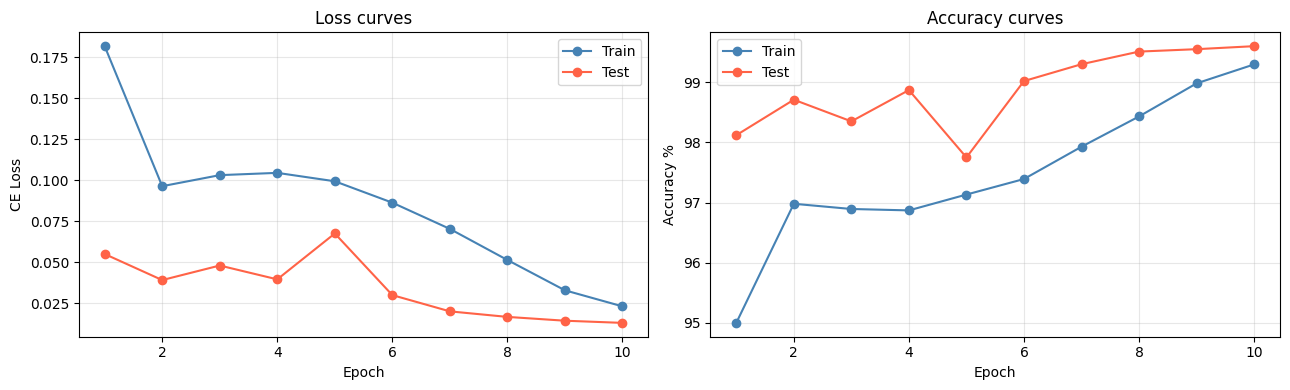

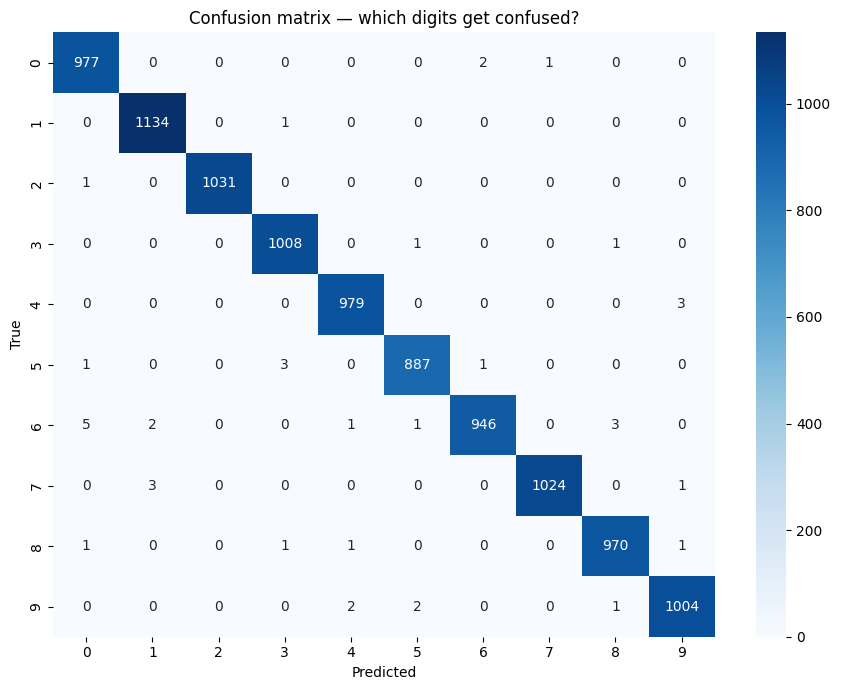


The model's worst mistakes:


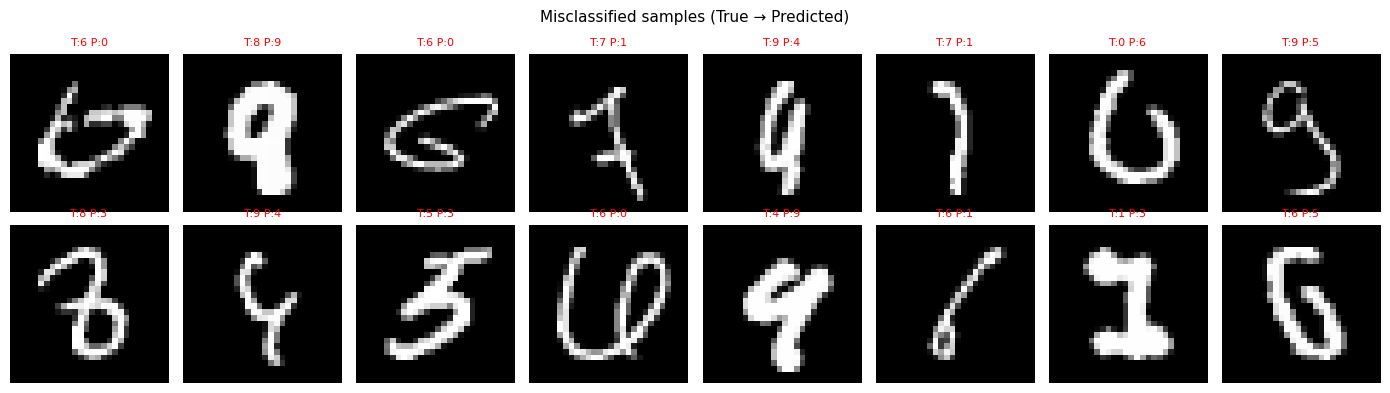

In [6]:
print("\n" + "=" * 55)
print("SECTION D: Visualise results")
print("=" * 55)

# ── Training curves ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
epochs_range = range(1, 11)

ax1.plot(epochs_range, history["train_loss"], 'o-', label='Train', color='steelblue')
ax1.plot(epochs_range, history["test_loss"],  'o-', label='Test',  color='tomato')
ax1.set_title("Loss curves"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("CE Loss")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, [a*100 for a in history["train_acc"]], 'o-', label='Train', color='steelblue')
ax2.plot(epochs_range, [a*100 for a in history["test_acc"]],  'o-', label='Test',  color='tomato')
ax2.set_title("Accuracy curves"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy %")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# ── Confusion matrix ──────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds, all_labels = [], []
cnn_model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        out = cnn_model(images.to(device))
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title("Confusion matrix — which digits get confused?")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()

# ── Show worst mistakes ───────────────────────────────────────────────────
print("\nThe model's worst mistakes:")
wrong_idx = [i for i,(p,t) in enumerate(zip(all_preds, all_labels)) if p != t]
images_all = test_dataset.data.numpy()   # raw pixels
labels_all = test_dataset.targets.numpy()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flatten()):
    if i >= len(wrong_idx): break
    idx = wrong_idx[i]
    ax.imshow(images_all[idx], cmap='gray')
    ax.set_title(f"T:{labels_all[idx]} P:{all_preds[idx]}", fontsize=8, color='red')
    ax.axis('off')
plt.suptitle("Misclassified samples (True → Predicted)", fontsize=11)
plt.tight_layout(); plt.show()

Section E — Visualise what the filters learned



SECTION E: What did the filters learn?
Conv1 filters shape: torch.Size([32, 1, 3, 3])


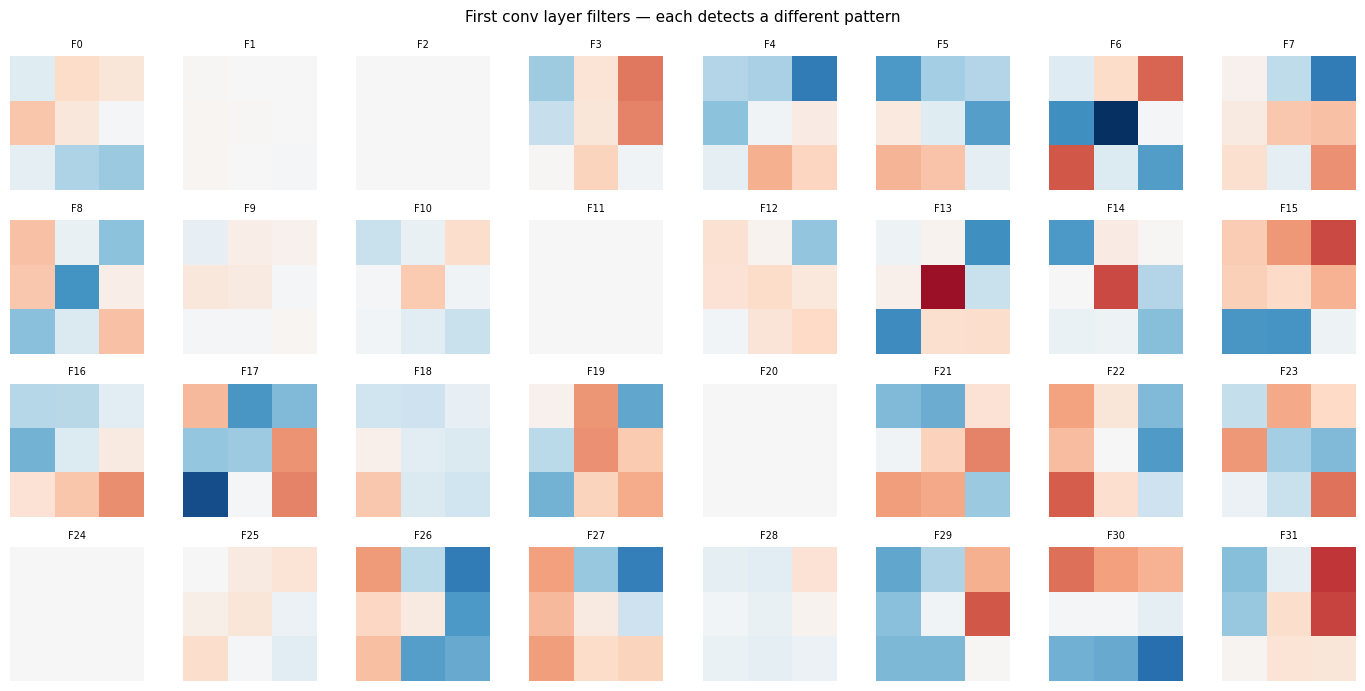

Feature map shape: torch.Size([1, 32, 28, 28])


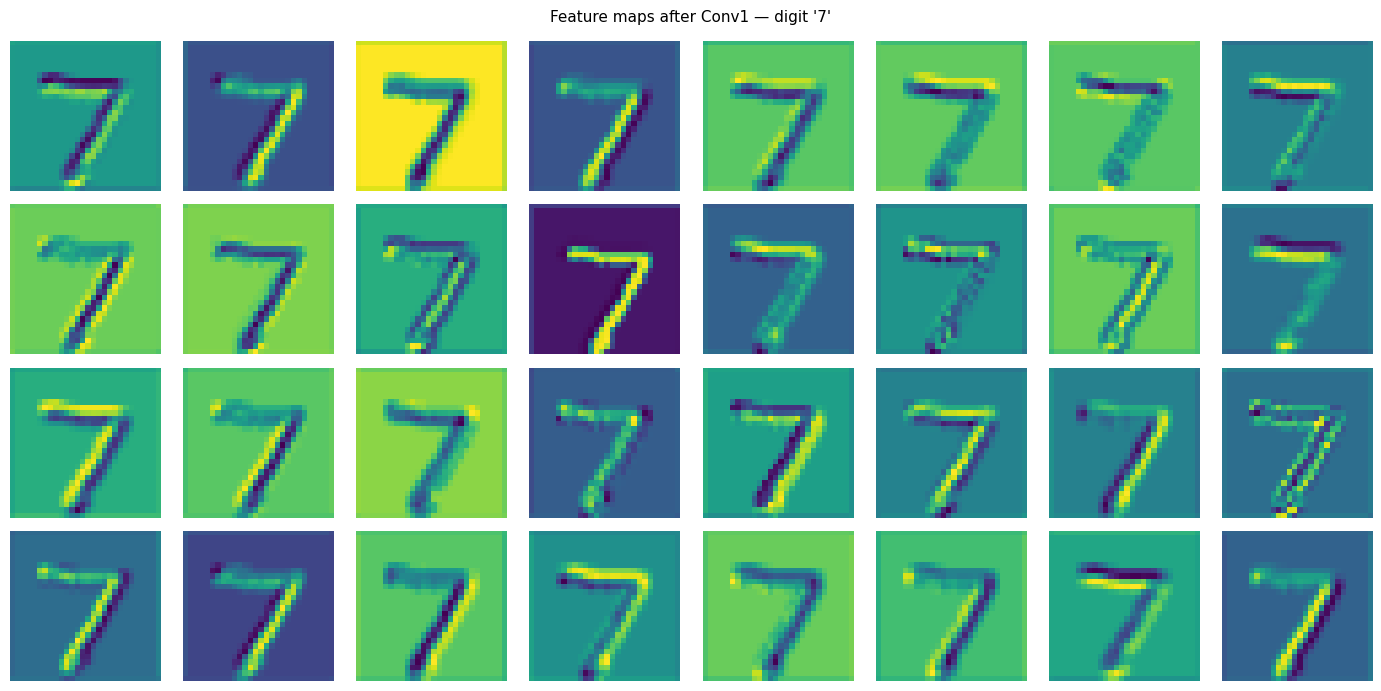

In [7]:
print("\n" + "=" * 55)
print("SECTION E: What did the filters learn?")
print("=" * 55)

# First conv layer filters — 32 filters of size 3×3
filters = cnn_model.conv_block1[0].weight.data.cpu()  # shape: (32, 1, 3, 3)
print(f"Conv1 filters shape: {filters.shape}")

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    filt = filters[i, 0].numpy()   # (3,3)
    ax.imshow(filt, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_title(f"F{i}", fontsize=7)
    ax.axis('off')
plt.suptitle("First conv layer filters — each detects a different pattern", fontsize=11)
plt.tight_layout(); plt.show()

# Feature maps — what does the network see for one digit?
sample_img, sample_label = test_dataset[0]
sample_img = sample_img.unsqueeze(0).to(device)  # (1,1,28,28)

cnn_model.eval()
with torch.no_grad():
    feature_maps = cnn_model.conv_block1[:2](sample_img)  # after first conv+bn+relu
print(f"Feature map shape: {feature_maps.shape}")        # (1, 32, 28, 28)

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(feature_maps[0, i].cpu(), cmap='viridis')
    ax.axis('off')
plt.suptitle(f"Feature maps after Conv1 — digit '{sample_label}'", fontsize=11)
plt.tight_layout(); plt.show()

Section F — Save and load the model


In [8]:
print("\n" + "=" * 55)
print("SECTION F: Save & load — production pattern")
print("=" * 55)

# Save — only the state dict (weights), not the full model object
torch.save(cnn_model.state_dict(), "mnist_cnn.pth")
print("Model saved to mnist_cnn.pth")
print(f"File size: {__import__('os').path.getsize('mnist_cnn.pth') / 1024:.1f} KB")

# Load — recreate the architecture, then load weights
loaded_model = MnistCNN().to(device)
loaded_model.load_state_dict(torch.load("mnist_cnn.pth", map_location=device))
loaded_model.eval()

# Verify it's identical
with torch.no_grad():
    sample, label = test_dataset[42]
    out = loaded_model(sample.unsqueeze(0).to(device))
    pred = out.argmax(1).item()
    prob = torch.softmax(out, dim=1).max().item()
    print(f"\nLoaded model prediction: {pred} (true: {label}) confidence: {prob*100:.1f}%")


SECTION F: Save & load — production pattern
Model saved to mnist_cnn.pth
File size: 3420.6 KB

Loaded model prediction: 4 (true: 4) confidence: 100.0%


Section G — Data augmentation



SECTION G: Data augmentation — free extra training data


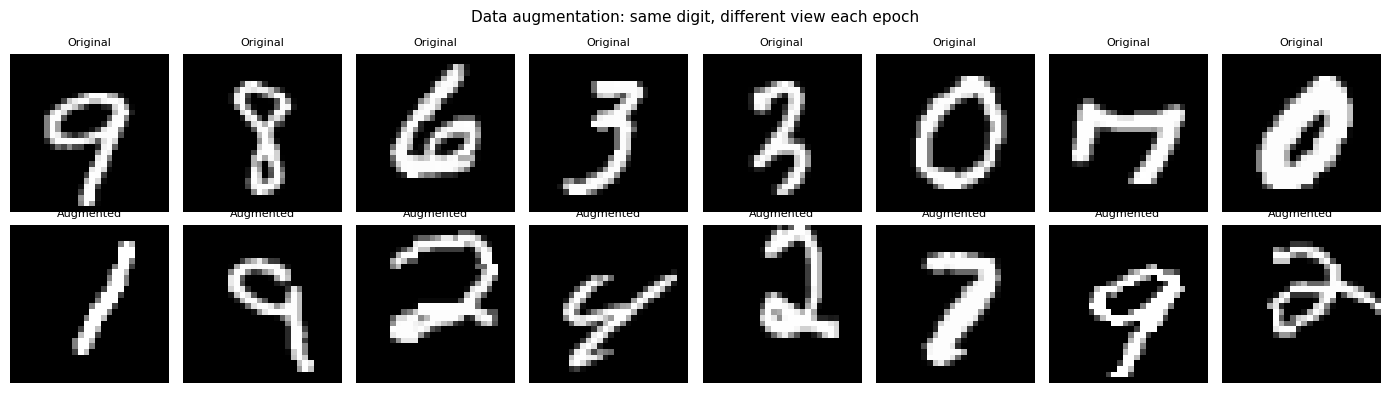

Augmentation helps most when your dataset is small.
For MNIST it adds ~0.1-0.2% accuracy. For medical imaging it can be +10%.


In [9]:
print("\n" + "=" * 55)
print("SECTION G: Data augmentation — free extra training data")
print("=" * 55)

# Augmentation randomly transforms images during training
# The network sees a different version each epoch → harder to overfit
augmented_transform = transforms.Compose([
    transforms.RandomRotation(10),          # rotate ±10 degrees
    transforms.RandomAffine(
        degrees=0, translate=(0.1, 0.1)     # shift up/down/left/right 10%
    ),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Only apply to training set — test set always uses clean transform
aug_train = datasets.MNIST('./data', train=True,  transform=augmented_transform)
aug_loader = DataLoader(aug_train, batch_size=64, shuffle=True)

# Show augmented vs original
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
orig_imgs, _ = next(iter(train_loader))
aug_imgs,  _ = next(iter(aug_loader))
for i in range(8):
    axes[0, i].imshow(orig_imgs[i].squeeze(), cmap='gray')
    axes[0, i].set_title("Original", fontsize=8); axes[0, i].axis('off')
    axes[1, i].imshow(aug_imgs[i].squeeze(),  cmap='gray')
    axes[1, i].set_title("Augmented", fontsize=8); axes[1, i].axis('off')
plt.suptitle("Data augmentation: same digit, different view each epoch", fontsize=11)
plt.tight_layout(); plt.show()

print("Augmentation helps most when your dataset is small.")
print("For MNIST it adds ~0.1-0.2% accuracy. For medical imaging it can be +10%.")